In [1]:
import matplotlib
import numpy as np
from matplotlib import pyplot as plt

In [2]:
from cr_knee_fit import plotting  # noqa: F401
from cr_knee_fit.experiments import Experiment
from cr_knee_fit.fit_data import GenericExperimentData


def make_demo_data(lambda_syst: float, error_size: float) -> GenericExperimentData:
    size = 15
    return GenericExperimentData(
        x=np.geomspace(1e2, 1e5, size),
        y=np.zeros(size),
        err_stat=np.zeros((size, 2)),
        err_syst=error_size * np.ones((size, 2)),
        experiment=Experiment("dummy", "dummy"),
        systematics_correlation_length=lambda_syst,
    )

In [13]:
def plot_errcov(
    data: GenericExperimentData,
    custom_errcov: np.ndarray | None = None,
    error_size: float | None = None,
):
    fig, axes = plt.subplots(nrows=2, figsize=(2.5, 5))
    if custom_errcov is not None:
        errcov = custom_errcov
    else:
        errcov = data.standard_err_cov
    ax_cov = axes[0]
    ax_cov.imshow(
        errcov,
        origin="lower",
        norm=Normalize(0, error_size**2) if error_size is not None else None,
        cmap="inferno",
        aspect="auto",
    )
    ax_cov.set_xticks([])
    ax_cov.set_yticks([])

    ax_smpl = axes[1]
    cmap = CARTO_VIVID
    for i in range(6):
        sample = np.random.multivariate_normal(mean=data.y, cov=errcov)
        ax_smpl.plot(data.x, sample, ".-", color=cmap(i))
        ax_smpl.set_yticks([])
    ax_smpl.set_xscale("log")
    step = data.x[1] / data.x[0]
    ax_smpl.set_xlim(data.x[0] / np.sqrt(step), data.x[-1] * np.sqrt(step))
    if error_size is not None:
        for sign in (1, -1):
            ax_smpl.plot(
                data.x, sign * error_size * np.ones_like(data.x), color="gray", linestyle=":"
            )
        ax_smpl.axhline(0, color="gray", linestyle="--")

    fig.suptitle(
        "$ \\lambda_\\text{syst} = "
        + f"{data.systematics_correlation_length or data.default_systematics_correlation_length:.2g} $"
    )
    fig.tight_layout()
    return fig

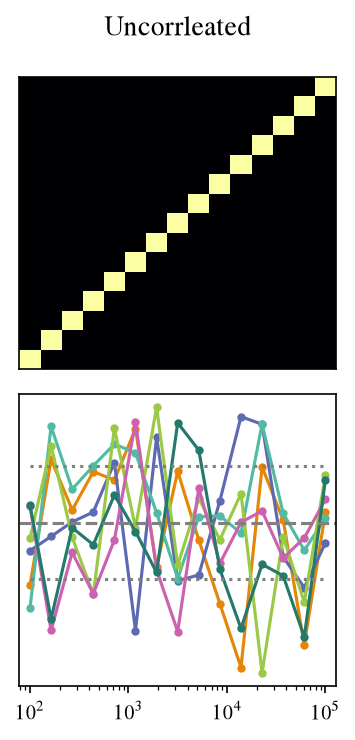

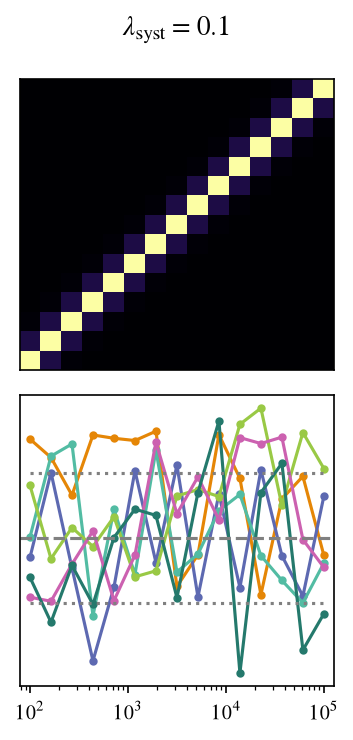

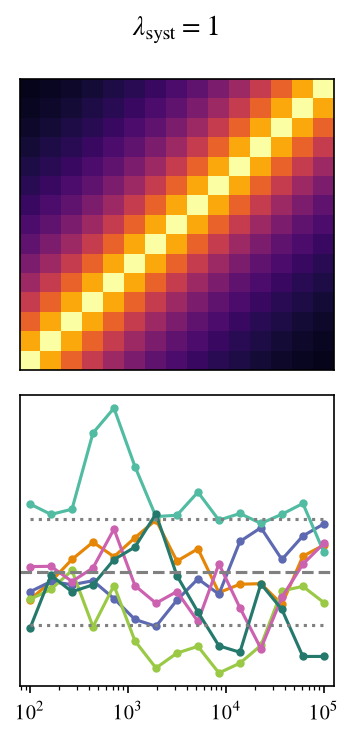

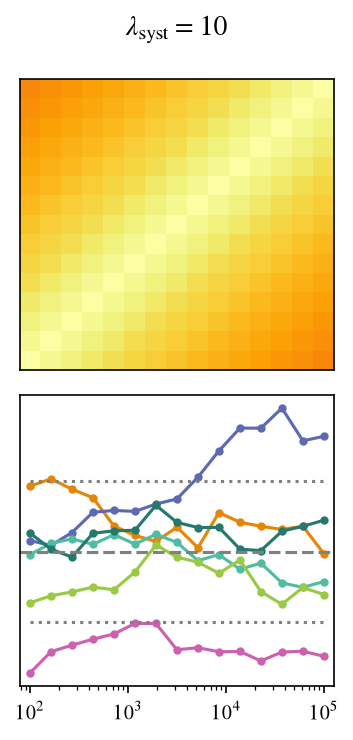

In [16]:
from matplotlib.colors import Normalize

from cr_knee_fit.plotting import CARTO_VIVID

error_size = 1.0
for lambda_syst in (1e-6, 0.1, 1.0, 10):
    data = make_demo_data(lambda_syst, error_size)
    fig = plot_errcov(data, error_size=error_size)
    if lambda_syst < 0.01:
        fig.suptitle("Uncorrleated")
        fig.tight_layout()

Text(0.5, 0.98, 'DAMPE')

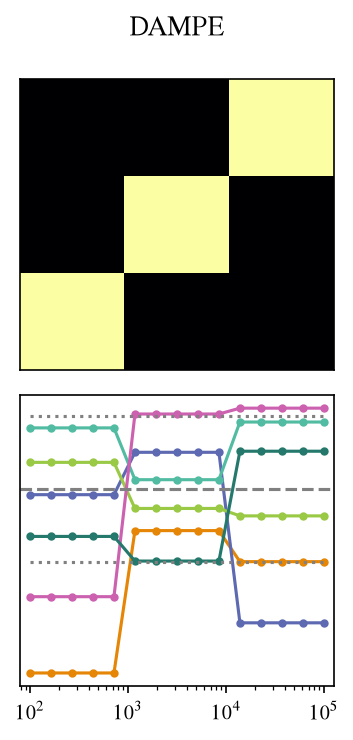

In [15]:
b1 = np.ones((5, 5))
b0 = np.zeros((5, 5))

fig = plot_errcov(
    make_demo_data(0.0, 1.0),
    custom_errcov=np.block(
        [
            [b1, b0, b0],
            [b0, b1, b0],
            [b0, b0, b1],
        ]
    ),
    error_size=error_size,
)
fig.suptitle("DAMPE")

In [11]:
from cr_knee_fit import experiments
from cr_knee_fit.elements import Element
from cr_knee_fit.fit_data import CRSpectrumData

data = CRSpectrumData.load(exp=experiments.dampe, element=Element.H, R_bounds=(0, np.inf))

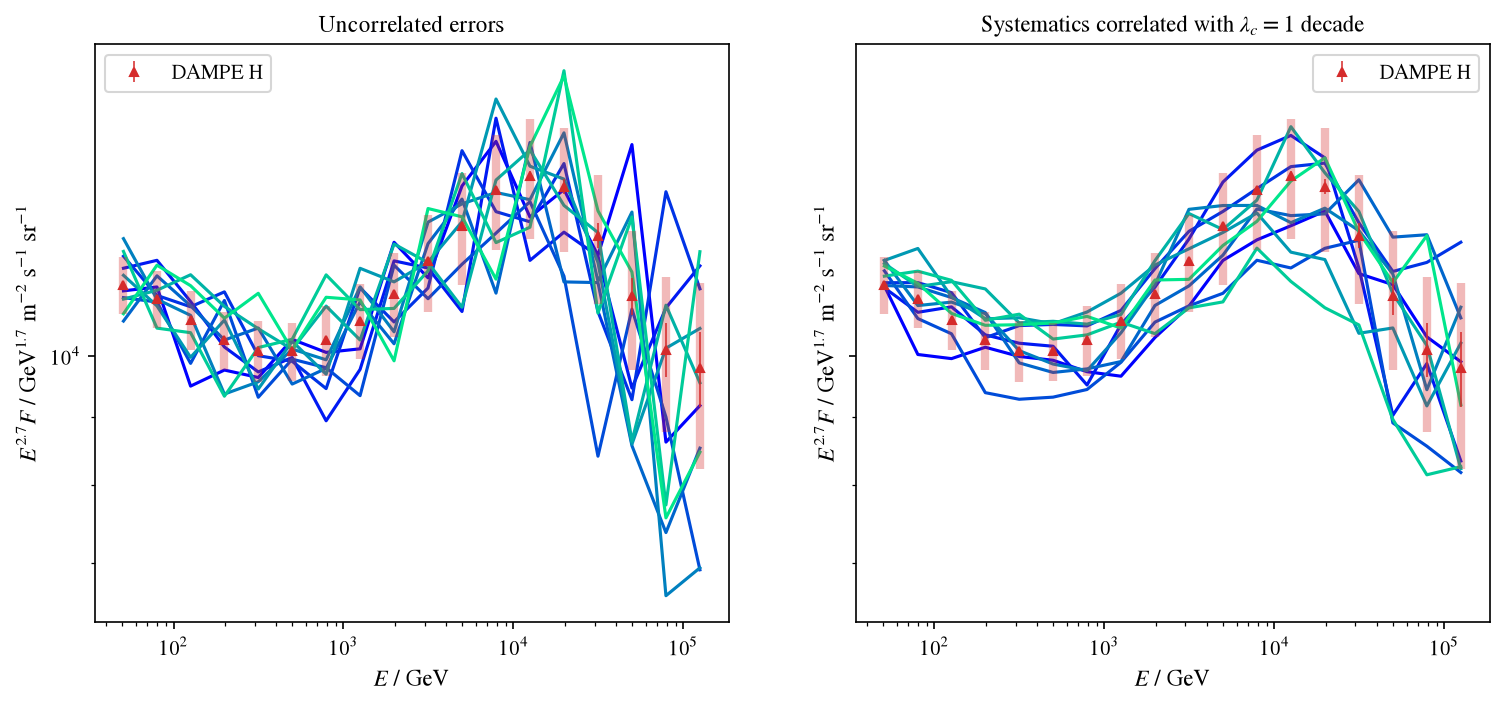

In [12]:
fig, axes = plt.subplots(ncols=2, figsize=(12, 5), sharex=True, sharey=True)

scale = 2.7

for idx, ax in enumerate(axes):
    data.plot(scale=scale, ax=ax)

    if idx == 0:
        corr_length = 1e-6
        ax.set_title("Uncorrelated errors")
    else:
        corr_length = 1.0
        ax.set_title(f"Systematics correlated with $\\lambda_c = {corr_length:.2g}$ decade")

    cov = data.d.err_cov(corr_length=corr_length)
    mu = data.d.y
    n_samples = 10
    cmap = matplotlib.colormaps["winter"]
    for i_smpl in range(n_samples):
        sample = np.random.multivariate_normal(mean=mu, cov=cov)
        ax.plot(
            data.d.x,
            data.d.scale_factor(scale) * sample,
            "-",
            color=cmap(i_smpl / n_samples),
            zorder=-1,
        )

for ax in axes:
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.legend()